# Stage A — Greenwich Zoning Code Reader

## Phase 1 — Collection

This notebook implements the collection phase of the Stage A zoning-code reader

The collection phase will eventually convert the official Greenwich Building Zone Regulations PDF into a traceable, layout-aware, structured representation that supports:

- native text and OCR extraction
- page-level quality routing
- document hierarchy construction
- district-anchor detection
- cross-reference resolution
- townwide-rule collection
- structural table parsing
- base-district and overlay separation
- district evidence-bundle construction


**Raw-source policy:** Files inside `data/raw/greenwich/` are treated as immutable evidence. The notebook may read and hash the source PDF, but it must never overwrite, edit, annotate, or save derived content over it

## Step 1 — Notebook setup and inputs

### Objective

Load and validate the manually downloaded Greenwich Building Zone Regulations PDF; define extraction settings, output folders, initial regex patterns, page-quality weights, and routing thresholds

### Expected outputs

This section should produce:

1. A path summary confirming that the Stage A folder structure is available
2. A source-document record containing the local PDF path, page count, PDF metadata, retrieval date, and SHA-256 hash
3. A configuration summary table containing page-quality thresholds, enabled modules, and library versions
4. A rendered preview of page 1, confirming that the correct source document loaded

### Scope boundary

This section does not yet extract the document text, calculate actual quality scores, run OCR, classify headings, identify districts, parse tables, or create evidence bundles

In [1]:
from __future__ import annotations

import hashlib
import json
import platform
import sys
from datetime import datetime, timezone
from pathlib import Path

import fitz  # PyMuPDF
import pymupdf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pdfplumber
import re
import pyarrow as pa

In [2]:
def find_stage_a_root(start_path: Path) -> Path:
    """
    Walk upward from the current working directory until the Stage A project
    root is found. The Stage A root must contain data/, notebooks/, and README.md.
    """
    start_path = start_path.resolve()

    for candidate in [start_path, *start_path.parents]:
        required_paths = [
            candidate / "data",
            candidate / "notebooks",
            candidate / "README.md",
        ]

        if all(path.exists() for path in required_paths):
            return candidate

    raise FileNotFoundError(
        "Could not locate the Stage A project root. "
        "Make sure this notebook is saved inside "
        "Stage_A_Zoning_Code_Reader/notebooks/ and that the Stage A folder "
        "contains data/, notebooks/, and README.md."
    )


STAGE_A_ROOT = find_stage_a_root(Path.cwd())

DATA_DIR = STAGE_A_ROOT / "data"
RAW_DIR = DATA_DIR / "raw" / "greenwich"
INTERIM_DIR = DATA_DIR / "interim"
PROCESSED_DIR = DATA_DIR / "processed"

OUTPUT_DIR = STAGE_A_ROOT / "outputs"
FIGURES_DIR = OUTPUT_DIR / "figures"
TABLES_DIR = OUTPUT_DIR / "tables"
LOGS_DIR = OUTPUT_DIR / "logs"
REVIEW_DIR = OUTPUT_DIR / "review"

NOTEBOOK_DIR = STAGE_A_ROOT / "notebooks"
SRC_DIR = STAGE_A_ROOT / "src"
TESTS_DIR = STAGE_A_ROOT / "tests"

for directory in [
    RAW_DIR,
    INTERIM_DIR,
    PROCESSED_DIR,
    FIGURES_DIR,
    TABLES_DIR,
    LOGS_DIR,
    REVIEW_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

path_summary_df = pd.DataFrame(
    {
        "name": [
            "stage_a_root",
            "raw_source_directory",
            "interim_directory",
            "processed_directory",
            "figures_directory",
            "tables_directory",
            "logs_directory",
            "review_directory",
        ],
        "path": [
            str(STAGE_A_ROOT),
            str(RAW_DIR),
            str(INTERIM_DIR),
            str(PROCESSED_DIR),
            str(FIGURES_DIR),
            str(TABLES_DIR),
            str(LOGS_DIR),
            str(REVIEW_DIR),
        ],
    }
)

path_summary_df

,name,path
0,stage_a_root,/Users/sierramendoza/Documents/HAP-Repository/...
1,raw_source_directory,/Users/sierramendoza/Documents/HAP-Repository/...
2,interim_directory,/Users/sierramendoza/Documents/HAP-Repository/...
3,processed_directory,/Users/sierramendoza/Documents/HAP-Repository/...
4,figures_directory,/Users/sierramendoza/Documents/HAP-Repository/...
5,tables_directory,/Users/sierramendoza/Documents/HAP-Repository/...
6,logs_directory,/Users/sierramendoza/Documents/HAP-Repository/...
7,review_directory,/Users/sierramendoza/Documents/HAP-Repository/...


### Canonical source-document configuration

The initial test uses one full-version Greenwich zoning-code PDF as the canonical source.

The source file must be located at:

```text
data/raw/greenwich/
```

The filename, document version date, retrieval date, source URL, and SHA-256 hash are recorded so every later extracted token, table cell, district bundle, and model result can be tied to one identifiable source document

The regex patterns below are intentionally preliminary configuration patterns. They are not yet validated against the actual Greenwich document and will be refined after the native extraction and heading-inspection stages

In [3]:
SOURCE_CONFIG = {
    "jurisdiction": "Greenwich, Connecticut",
    "document_name": "Town of Greenwich Building Zone Regulations",
    "pdf_filename": "greenwich_building_zone_regulations_full_2023-08.pdf",
    "source_url": "https://www.greenwichct.gov/442/Building-Zone-Regulations",
    "document_version_date": "August 2023",
    "date_retrieved": datetime.now(timezone.utc).date().isoformat(),
    "canonical_source": True,
}

PDF_PATH = RAW_DIR / SOURCE_CONFIG["pdf_filename"]

QUALITY_CONFIG = {
    "weights": {
        "text_coverage": 0.35,
        "character_quality": 0.25,
        "reading_order": 0.20,
        "table_integrity": 0.20,
    },
    "thresholds": {
        "high_quality_native_threshold": 0.85,
        "manual_review_threshold": 0.50,
    },
}

MODULE_CONFIG = {
    "native_pdf_extraction": True,
    "page_quality_scoring": True,
    "targeted_ocr": False,
    "dual_stream_reconciliation": False,
    "hierarchy_tree_construction": False,
    "district_anchor_detection": False,
    "cross_reference_resolution": False,
    "townwide_rule_library": False,
    "structural_table_parsing": False,
    "overlay_zone_separation": False,
    "conflict_resolution": False,
    "gis_polygon_join": False,
}

REGEX_PATTERNS = {
    "title": r"^(title|chapter)\s+[\wivxlcdm]+",
    "article": r"^article\s+[\wivxlcdm]+",
    "section": r"^(section|sec\.?|§)\s*\d+([.-]\d+)*",
    "subsection": r"^(\([a-z0-9]+\)|\d+\.\d+([.-]\d+)*)",
    "appendix": r"^appendix\s+[\wivxlcdm]+",
    "district_heading": (
        r"\b(RA-\d+|R-\d+|B-[A-Z0-9-]+|CGB|CGBR|"
        r"LB|GB|GBO|HO|CO|M[0-9A-Z-]*)\b"
    ),
    "citation": (
        r"(§\s*\d+([.-]\d+)*(\([a-z0-9]+\))?)|"
        r"(section\s+\d+([.-]\d+)*)|"
        r"(article\s+[IVXLCDM]+(\.[A-Z])?)"
    ),
}

assert abs(sum(QUALITY_CONFIG["weights"].values()) - 1.0) < 1e-9, (
    "Page-quality weights must sum to 1.0."
)

assert (
    QUALITY_CONFIG["thresholds"]["manual_review_threshold"]
    < QUALITY_CONFIG["thresholds"]["high_quality_native_threshold"]
), (
    "The manual-review threshold must be lower than the high-quality "
    "native-extraction threshold."
)

print(f"Expected source PDF: {PDF_PATH}")
print(f"Source PDF exists: {PDF_PATH.exists()}")

Expected source PDF: /Users/sierramendoza/Documents/HAP-Repository/Stage_A_Zoning_Code_Reader/data/raw/greenwich/greenwich_building_zone_regulations_full_2023-08.pdf
Source PDF exists: True


In [4]:
def sha256_file(file_path: Path, chunk_size: int = 1_048_576) -> str:
    """
    Calculate the SHA-256 hash of a file in chunks, avoiding loading the full
    PDF into memory at one time.
    """
    digest = hashlib.sha256()

    with file_path.open("rb") as file_handle:
        while chunk := file_handle.read(chunk_size):
            digest.update(chunk)

    return digest.hexdigest()


if not PDF_PATH.exists():
    available_pdfs = sorted(
        [file.name for file in RAW_DIR.glob("*.pdf")]
        + [file.name for file in RAW_DIR.glob("*.PDF")]
    )

    raise FileNotFoundError(
        f"Expected PDF was not found:\n{PDF_PATH}\n\n"
        f"PDF files currently in {RAW_DIR}:\n{available_pdfs}\n\n"
        "Download the official full-version Greenwich Building Zone Regulations PDF, "
        "place it in Stage_A_Zoning_Code_Reader/data/raw/greenwich/, and either "
        "use the expected filename or update SOURCE_CONFIG['pdf_filename']."
    )

PDF_SHA256 = sha256_file(PDF_PATH)
PDF_SIZE_MB = PDF_PATH.stat().st_size / (1024 ** 2)

print(f"Validated source file: {PDF_PATH.name}")
print(f"File size: {PDF_SIZE_MB:.2f} MB")
print(f"SHA-256: {PDF_SHA256}")

Validated source file: greenwich_building_zone_regulations_full_2023-08.pdf
File size: 4.11 MB
SHA-256: 18417c5e9074d765ab4483571b9ac3d6aeb162b37b1b302f7a8ce1f13e963dcb


In [5]:
with fitz.open(PDF_PATH) as pdf_document:
    PDF_PAGE_COUNT = pdf_document.page_count
    PDF_METADATA = {
        key: value
        for key, value in pdf_document.metadata.items()
        if value not in (None, "")
    }

with pdfplumber.open(PDF_PATH) as plumber_document:
    PDFPLUMBER_METADATA = plumber_document.metadata or {}

pdf_metadata_rows = [
    {"field": "page_count", "value": PDF_PAGE_COUNT},
    {"field": "file_size_mb", "value": round(PDF_SIZE_MB, 3)},
    {"field": "sha256", "value": PDF_SHA256},
]

for key, value in PDF_METADATA.items():
    pdf_metadata_rows.append({"field": f"pymupdf_{key}", "value": value})

for key, value in PDFPLUMBER_METADATA.items():
    pdf_metadata_rows.append({"field": f"pdfplumber_{key}", "value": value})

pdf_metadata_df = pd.DataFrame(pdf_metadata_rows).drop_duplicates()

pdf_metadata_df

,field,value
0,page_count,313
1,file_size_mb,4.115
2,sha256,18417c5e9074d765ab4483571b9ac3d6aeb162b37b1b30...
3,pymupdf_format,PDF 1.6
4,pymupdf_author,Patrick LaRow
5,pymupdf_subject,BUILDING ZONE REGULATIONS
6,pymupdf_creator,Adobe Acrobat Pro 2017 17.12.30205
7,pymupdf_producer,Adobe Acrobat Pro 2017 17.12.30205
8,pymupdf_creationDate,D:20230802110515-04'00'
9,pymupdf_modDate,D:20230802110515-04'00'


In [6]:
def package_version(package_name: str) -> str:
    try:
        from importlib.metadata import version
        return version(package_name)
    except Exception:
        return "not available"


library_versions = {
    "python": sys.version.split()[0],
    "operating_system": platform.platform(),
    "pandas": package_version("pandas"),
    "pymupdf": package_version("PyMuPDF"),
    "pdfplumber": package_version("pdfplumber"),
    "matplotlib": package_version("matplotlib"),
    "numpy": package_version("numpy"),
}

configuration_rows = [
    {
        "category": "source",
        "setting": "jurisdiction",
        "value": SOURCE_CONFIG["jurisdiction"],
    },
    {
        "category": "source",
        "setting": "document_name",
        "value": SOURCE_CONFIG["document_name"],
    },
    {
        "category": "source",
        "setting": "pdf_path",
        "value": str(PDF_PATH.relative_to(STAGE_A_ROOT)),
    },
    {
        "category": "source",
        "setting": "page_count",
        "value": PDF_PAGE_COUNT,
    },
    {
        "category": "source",
        "setting": "document_version_date",
        "value": SOURCE_CONFIG["document_version_date"],
    },
    {
        "category": "source",
        "setting": "date_retrieved",
        "value": SOURCE_CONFIG["date_retrieved"],
    },
    {
        "category": "source",
        "setting": "source_url",
        "value": SOURCE_CONFIG["source_url"],
    },
    {
        "category": "source",
        "setting": "sha256",
        "value": PDF_SHA256,
    },
]

for metric_name, weight in QUALITY_CONFIG["weights"].items():
    configuration_rows.append(
        {
            "category": "quality_weight",
            "setting": metric_name,
            "value": weight,
        }
    )

for threshold_name, threshold in QUALITY_CONFIG["thresholds"].items():
    configuration_rows.append(
        {
            "category": "quality_threshold",
            "setting": threshold_name,
            "value": threshold,
        }
    )

for module_name, enabled in MODULE_CONFIG.items():
    configuration_rows.append(
        {
            "category": "module",
            "setting": module_name,
            "value": enabled,
        }
    )

for library_name, version_string in library_versions.items():
    configuration_rows.append(
        {
            "category": "environment",
            "setting": library_name,
            "value": version_string,
        }
    )

config_summary_df = pd.DataFrame(configuration_rows)

config_summary_df

,category,setting,value
0,source,jurisdiction,"Greenwich, Connecticut"
1,source,document_name,Town of Greenwich Building Zone Regulations
2,source,pdf_path,data/raw/greenwich/greenwich_building_zone_reg...
3,source,page_count,313
4,source,document_version_date,August 2023
5,source,date_retrieved,2026-09-29
6,source,source_url,https://www.greenwichct.gov/442/Building-Zone-...
7,source,sha256,18417c5e9074d765ab4483571b9ac3d6aeb162b37b1b30...
8,quality_weight,text_coverage,0.35
9,quality_weight,character_quality,0.25


In [7]:
run_timestamp_utc = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")

source_metadata = {
    **SOURCE_CONFIG,
    "pdf_path_relative_to_stage_a": str(PDF_PATH.relative_to(STAGE_A_ROOT)),
    "pdf_page_count": PDF_PAGE_COUNT,
    "pdf_size_mb": round(PDF_SIZE_MB, 3),
    "sha256": PDF_SHA256,
    "pdf_metadata": PDF_METADATA,
    "pipeline_run_timestamp_utc": run_timestamp_utc,
    "quality_config": QUALITY_CONFIG,
    "module_config": MODULE_CONFIG,
    "regex_patterns": REGEX_PATTERNS,
    "library_versions": library_versions,
}

source_metadata_path = RAW_DIR / "source_metadata.json"
config_summary_path = TABLES_DIR / "step_01_configuration_summary.csv"

with source_metadata_path.open("w", encoding="utf-8") as file_handle:
    json.dump(source_metadata, file_handle, indent=2, ensure_ascii=False)

config_summary_df.to_csv(config_summary_path, index=False)

print(f"Saved source metadata: {source_metadata_path.relative_to(STAGE_A_ROOT)}")
print(f"Saved configuration table: {config_summary_path.relative_to(STAGE_A_ROOT)}")

Saved source metadata: data/raw/greenwich/source_metadata.json
Saved configuration table: outputs/tables/step_01_configuration_summary.csv


### Visual source validation

Before performing extraction, render page 1 and inspect it visually

This is a basic but important quality-control step. It confirms that:

- the file opens successfully through a PDF rendering engine
- the loaded file is the intended Greenwich zoning document
- the first page is not blank, corrupted, encrypted, or unrelated
- the page can be rendered for later layout-aware processing

The notebook saves this preview as a reusable run artifact in `outputs/figures/`

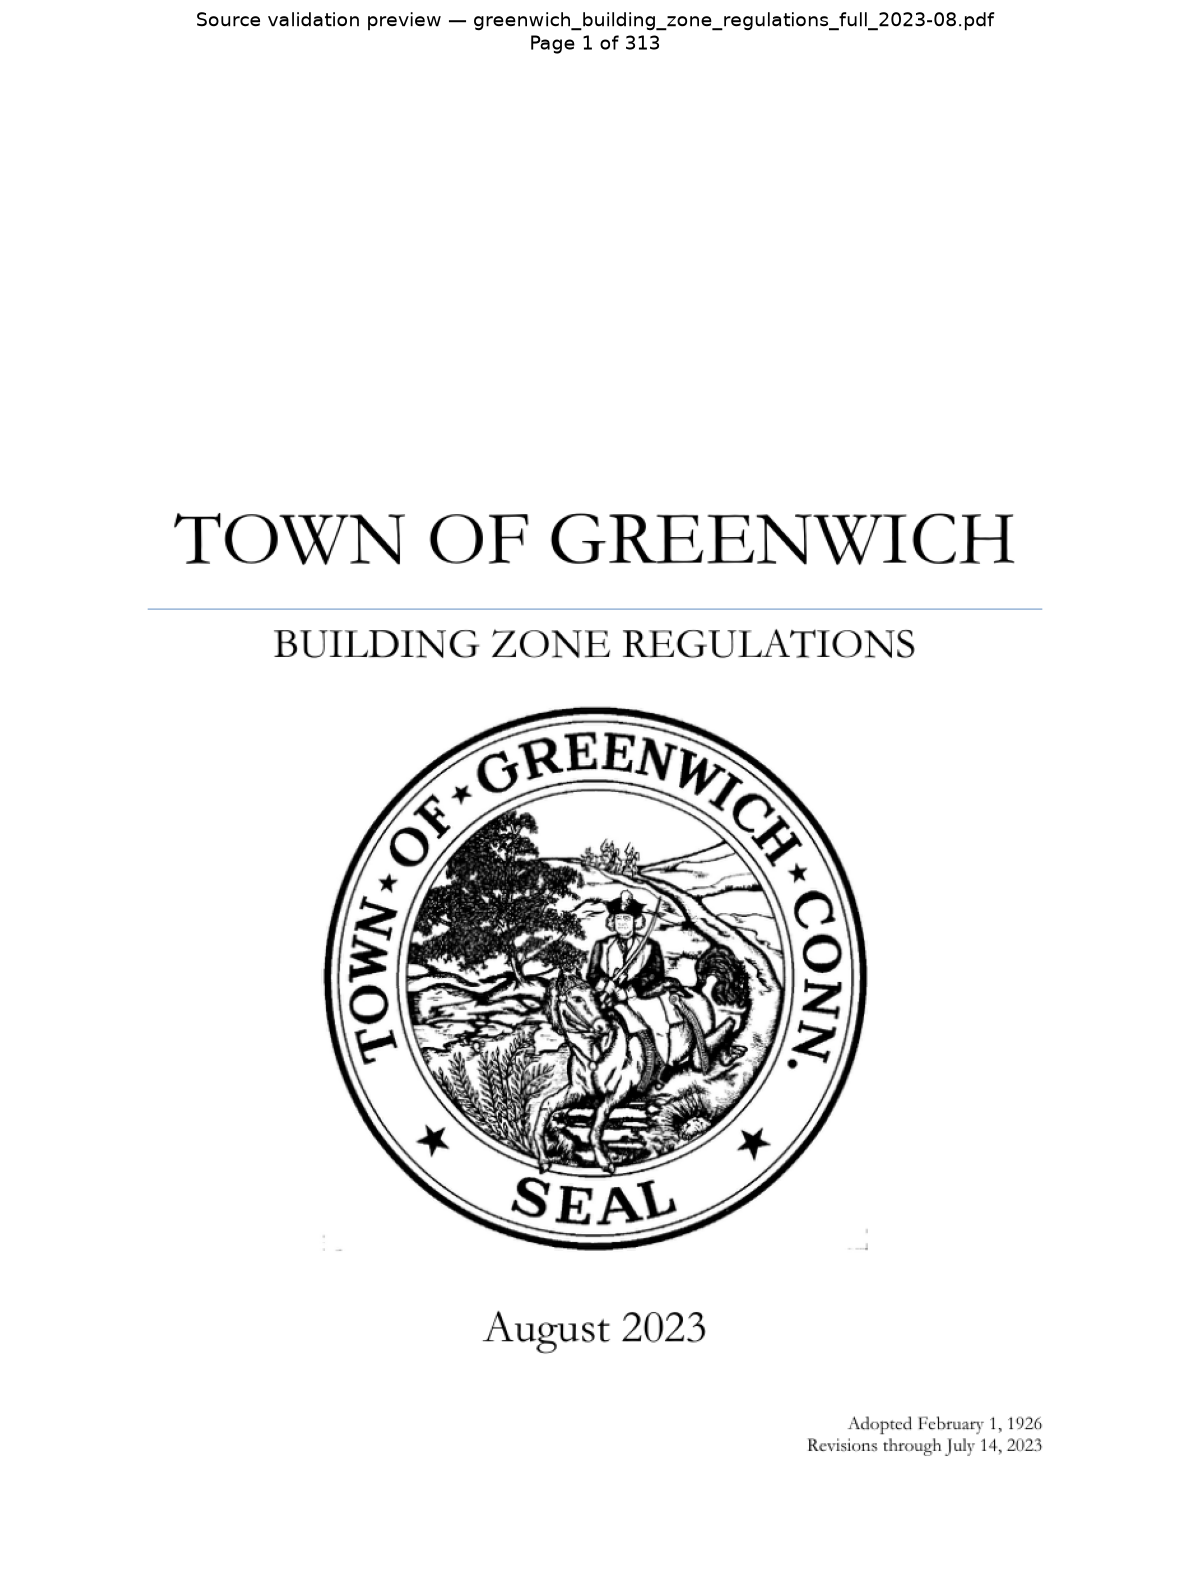

Saved first-page preview: outputs/figures/step_01_source_page_001_preview.png


In [8]:
def render_pdf_page(
    pdf_path: Path,
    page_number: int = 1,
    zoom: float = 1.5,
) -> np.ndarray:
    """
    Render a 1-indexed PDF page as an RGB NumPy image array.
    """
    if page_number < 1:
        raise ValueError("page_number must be at least 1.")

    with fitz.open(pdf_path) as document:
        if page_number > document.page_count:
            raise ValueError(
                f"page_number={page_number} exceeds the document page count "
                f"({document.page_count})."
            )

        page = document.load_page(page_number - 1)
        matrix = fitz.Matrix(zoom, zoom)
        pixmap = page.get_pixmap(matrix=matrix, alpha=False)

    image_shape = (pixmap.height, pixmap.width, 3)
    return np.frombuffer(pixmap.samples, dtype=np.uint8).reshape(image_shape)


first_page_image = render_pdf_page(PDF_PATH, page_number=1, zoom=1.5)

fig, ax = plt.subplots(figsize=(12, 16))
ax.imshow(first_page_image)
ax.set_title(
    f"Source validation preview — {PDF_PATH.name}\n"
    f"Page 1 of {PDF_PAGE_COUNT}",
    fontsize=14,
)
ax.axis("off")
plt.tight_layout()

first_page_preview_path = FIGURES_DIR / "step_01_source_page_001_preview.png"
fig.savefig(first_page_preview_path, dpi=200, bbox_inches="tight")

plt.show()

print(
    "Saved first-page preview: "
    f"{first_page_preview_path.relative_to(STAGE_A_ROOT)}"
)

## Step 2 — Source-document fingerprint and visual inspection

### Objective

Create a formal document-level fingerprint for the canonical Greenwich Building Zone Regulations PDF.

The fingerprint records both source provenance and automatically detected PDF characteristics so downstream extraction outputs can be traced to one exact input document

### Fingerprint fields

The record includes:

- stable document identifier
- jurisdiction and document title
- source URL and retrieval date
- local source path
- PDF filename, size, and page count
- SHA-256 file hash
- available PDF metadata
- detected or declared document-version information
- first-page textual evidence
- inspection and review status

### Outputs

This section produces:

1. A one-row document metadata dataframe
2. A PDF metadata-key inventory
3. A first-page text sample for manual verification
4. A high-resolution first-page rendered preview
5. A saved JSON fingerprint and CSV metadata table

### Scope boundary

This is still document-level validation. It does not yet create page-level text tokens, calculate quality scores, run OCR, or infer the legal hierarchy

In [9]:
import os
from typing import Any


def normalize_whitespace(text: str | None) -> str:
    """Collapse repeated whitespace while preserving the text content."""
    if not text:
        return ""

    return re.sub(r"\s+", " ", text).strip()


def safe_pdf_metadata(metadata: dict[str, Any] | None) -> dict[str, str]:
    """Keep non-empty PDF metadata values and convert them to strings."""
    metadata = metadata or {}

    return {
        str(key): normalize_whitespace(str(value))
        for key, value in metadata.items()
        if value not in (None, "", "null")
    }


def extract_first_page_text(pdf_path: Path) -> str:
    """Extract native text from page 1 for human source verification."""
    with fitz.open(pdf_path) as document:
        first_page = document.load_page(0)
        return normalize_whitespace(first_page.get_text("text"))


def detect_document_version(
    first_page_text: str,
    declared_version: str | None,
) -> dict[str, str]:
    """
    Identify likely version/update language from page-1 text.

    This is a heuristic inspection field, not a legal determination. The
    declared source version is preserved separately and should be manually
    verified against the document.
    """
    version_patterns = [
        r"(?:full\s+version|version|revised|revision|updated|effective|amended)"
        r"\s*(?:as\s+of|dated|on)?\s*[:\-]?\s*"
        r"([A-Z][a-z]+\s+\d{1,2},?\s+\d{4}|[A-Z][a-z]+\s+\d{4}|\d{1,2}/\d{1,2}/\d{2,4})",
        r"(?:ordinance|regulations?)\s*(?:no\.?|number)?\s*([A-Z0-9\-]+)",
    ]

    detected_matches = []

    for pattern in version_patterns:
        matches = re.findall(pattern, first_page_text, flags=re.IGNORECASE)
        detected_matches.extend(matches)

    detected_matches = [normalize_whitespace(match) for match in detected_matches]

    return {
        "declared_document_version": declared_version or "",
        "detected_version_candidates": " | ".join(
            dict.fromkeys(detected_matches)
        ),
        "version_detection_status": (
            "candidate_found" if detected_matches else "not_detected_on_page_1"
        ),
    }


def create_document_id(jurisdiction: str, sha256_hash: str) -> str:
    """
    Create a reproducible document ID from normalized jurisdiction text and
    the first 16 hexadecimal characters of the source-file SHA-256 hash.
    """
    jurisdiction_slug = re.sub(r"[^a-z0-9]+", "-", jurisdiction.lower()).strip("-")
    return f"{jurisdiction_slug}-{sha256_hash[:16]}"

In [10]:
first_page_text = extract_first_page_text(PDF_PATH)
first_page_text_preview = first_page_text[:2_500]

pymupdf_metadata_clean = safe_pdf_metadata(PDF_METADATA)
pdfplumber_metadata_clean = safe_pdf_metadata(PDFPLUMBER_METADATA)

version_info = detect_document_version(
    first_page_text=first_page_text,
    declared_version=SOURCE_CONFIG.get("document_version_date"),
)

DOCUMENT_ID = create_document_id(
    jurisdiction=SOURCE_CONFIG["jurisdiction"],
    sha256_hash=PDF_SHA256,
)

first_page_text_df = pd.DataFrame(
    {
        "field": [
            "document_id",
            "first_page_native_text_character_count",
            "first_page_text_preview",
        ],
        "value": [
            DOCUMENT_ID,
            len(first_page_text),
            first_page_text_preview,
        ],
    }
)

first_page_text_df

,field,value
0,document_id,greenwich-connecticut-18417c5e9074d765
1,first_page_native_text_character_count,112
2,first_page_text_preview,TOWN OF GREENWICH BUILDING ZONE REGULATIONS Au...


In [11]:
document_record = {
    "document_id": DOCUMENT_ID,
    "jurisdiction": SOURCE_CONFIG["jurisdiction"],
    "document_name": SOURCE_CONFIG["document_name"],
    "document_filename": PDF_PATH.name,
    "local_path_relative_to_stage_a": str(PDF_PATH.relative_to(STAGE_A_ROOT)),
    "source_url": SOURCE_CONFIG["source_url"],
    "date_retrieved": SOURCE_CONFIG["date_retrieved"],
    "declared_document_version": version_info["declared_document_version"],
    "detected_version_candidates": version_info["detected_version_candidates"],
    "version_detection_status": version_info["version_detection_status"],
    "file_size_mb": round(PDF_SIZE_MB, 3),
    "page_count": PDF_PAGE_COUNT,
    "sha256": PDF_SHA256,
    "first_page_native_text_character_count": len(first_page_text),
    "pdf_title": pymupdf_metadata_clean.get("title", ""),
    "pdf_author": pymupdf_metadata_clean.get("author", ""),
    "pdf_subject": pymupdf_metadata_clean.get("subject", ""),
    "pdf_creator": pymupdf_metadata_clean.get("creator", ""),
    "pdf_producer": pymupdf_metadata_clean.get("producer", ""),
    "pdf_creation_date": pymupdf_metadata_clean.get("creationDate", ""),
    "pdf_modification_date": pymupdf_metadata_clean.get("modDate", ""),
    "initial_inspection_status": "pending_manual_first_page_review",
    "pipeline_run_timestamp_utc": run_timestamp_utc,
}

document_metadata_df = pd.DataFrame([document_record])

document_metadata_df.T.rename(columns={0: "value"})

,value
document_id,greenwich-connecticut-18417c5e9074d765
jurisdiction,"Greenwich, Connecticut"
document_name,Town of Greenwich Building Zone Regulations
document_filename,greenwich_building_zone_regulations_full_2023-...
local_path_relative_to_stage_a,data/raw/greenwich/greenwich_building_zone_reg...
source_url,https://www.greenwichct.gov/442/Building-Zone-...
date_retrieved,2026-09-29
declared_document_version,August 2023
detected_version_candidates,August
version_detection_status,candidate_found


In [12]:
metadata_inventory_rows = []

for source_name, metadata_dict in [
    ("pymupdf", pymupdf_metadata_clean),
    ("pdfplumber", pdfplumber_metadata_clean),
]:
    for metadata_key, metadata_value in metadata_dict.items():
        metadata_inventory_rows.append(
            {
                "document_id": DOCUMENT_ID,
                "metadata_reader": source_name,
                "metadata_key": metadata_key,
                "metadata_value": metadata_value,
            }
        )

pdf_metadata_inventory_df = pd.DataFrame(metadata_inventory_rows)

if pdf_metadata_inventory_df.empty:
    pdf_metadata_inventory_df = pd.DataFrame(
        [
            {
                "document_id": DOCUMENT_ID,
                "metadata_reader": "none",
                "metadata_key": "no_embedded_metadata_detected",
                "metadata_value": "",
            }
        ]
    )

pdf_metadata_inventory_df

,document_id,metadata_reader,metadata_key,metadata_value
0,greenwich-connecticut-18417c5e9074d765,pymupdf,format,PDF 1.6
1,greenwich-connecticut-18417c5e9074d765,pymupdf,author,Patrick LaRow
2,greenwich-connecticut-18417c5e9074d765,pymupdf,subject,BUILDING ZONE REGULATIONS
3,greenwich-connecticut-18417c5e9074d765,pymupdf,creator,Adobe Acrobat Pro 2017 17.12.30205
4,greenwich-connecticut-18417c5e9074d765,pymupdf,producer,Adobe Acrobat Pro 2017 17.12.30205
5,greenwich-connecticut-18417c5e9074d765,pymupdf,creationDate,D:20230802110515-04'00'
6,greenwich-connecticut-18417c5e9074d765,pymupdf,modDate,D:20230802110515-04'00'
7,greenwich-connecticut-18417c5e9074d765,pdfplumber,Author,Patrick LaRow
8,greenwich-connecticut-18417c5e9074d765,pdfplumber,CreationDate,D:20230802110515-04'00'
9,greenwich-connecticut-18417c5e9074d765,pdfplumber,Creator,Adobe Acrobat Pro 2017 17.12.30205


### High-resolution first-page inspection

The rendered preview below is the authoritative visual validation artifact for this step.

Inspect the image and confirm:

- the title identifies the Town of Greenwich and Building Zone Regulations
- the document appears to be the intended full-version code
- the page is legible and has not rendered as blank or corrupted
- any visible version, amendment, or effective-date language agrees with the declared source configuration
- no unexpected cover page, password warning, scanning artifact, or unrelated document is present

After inspection, update the `initial_inspection_status` in the next code cell from `pending_manual_first_page_review` to either:

- `passed_manual_first_page_review`
- `flagged_for_source_review`

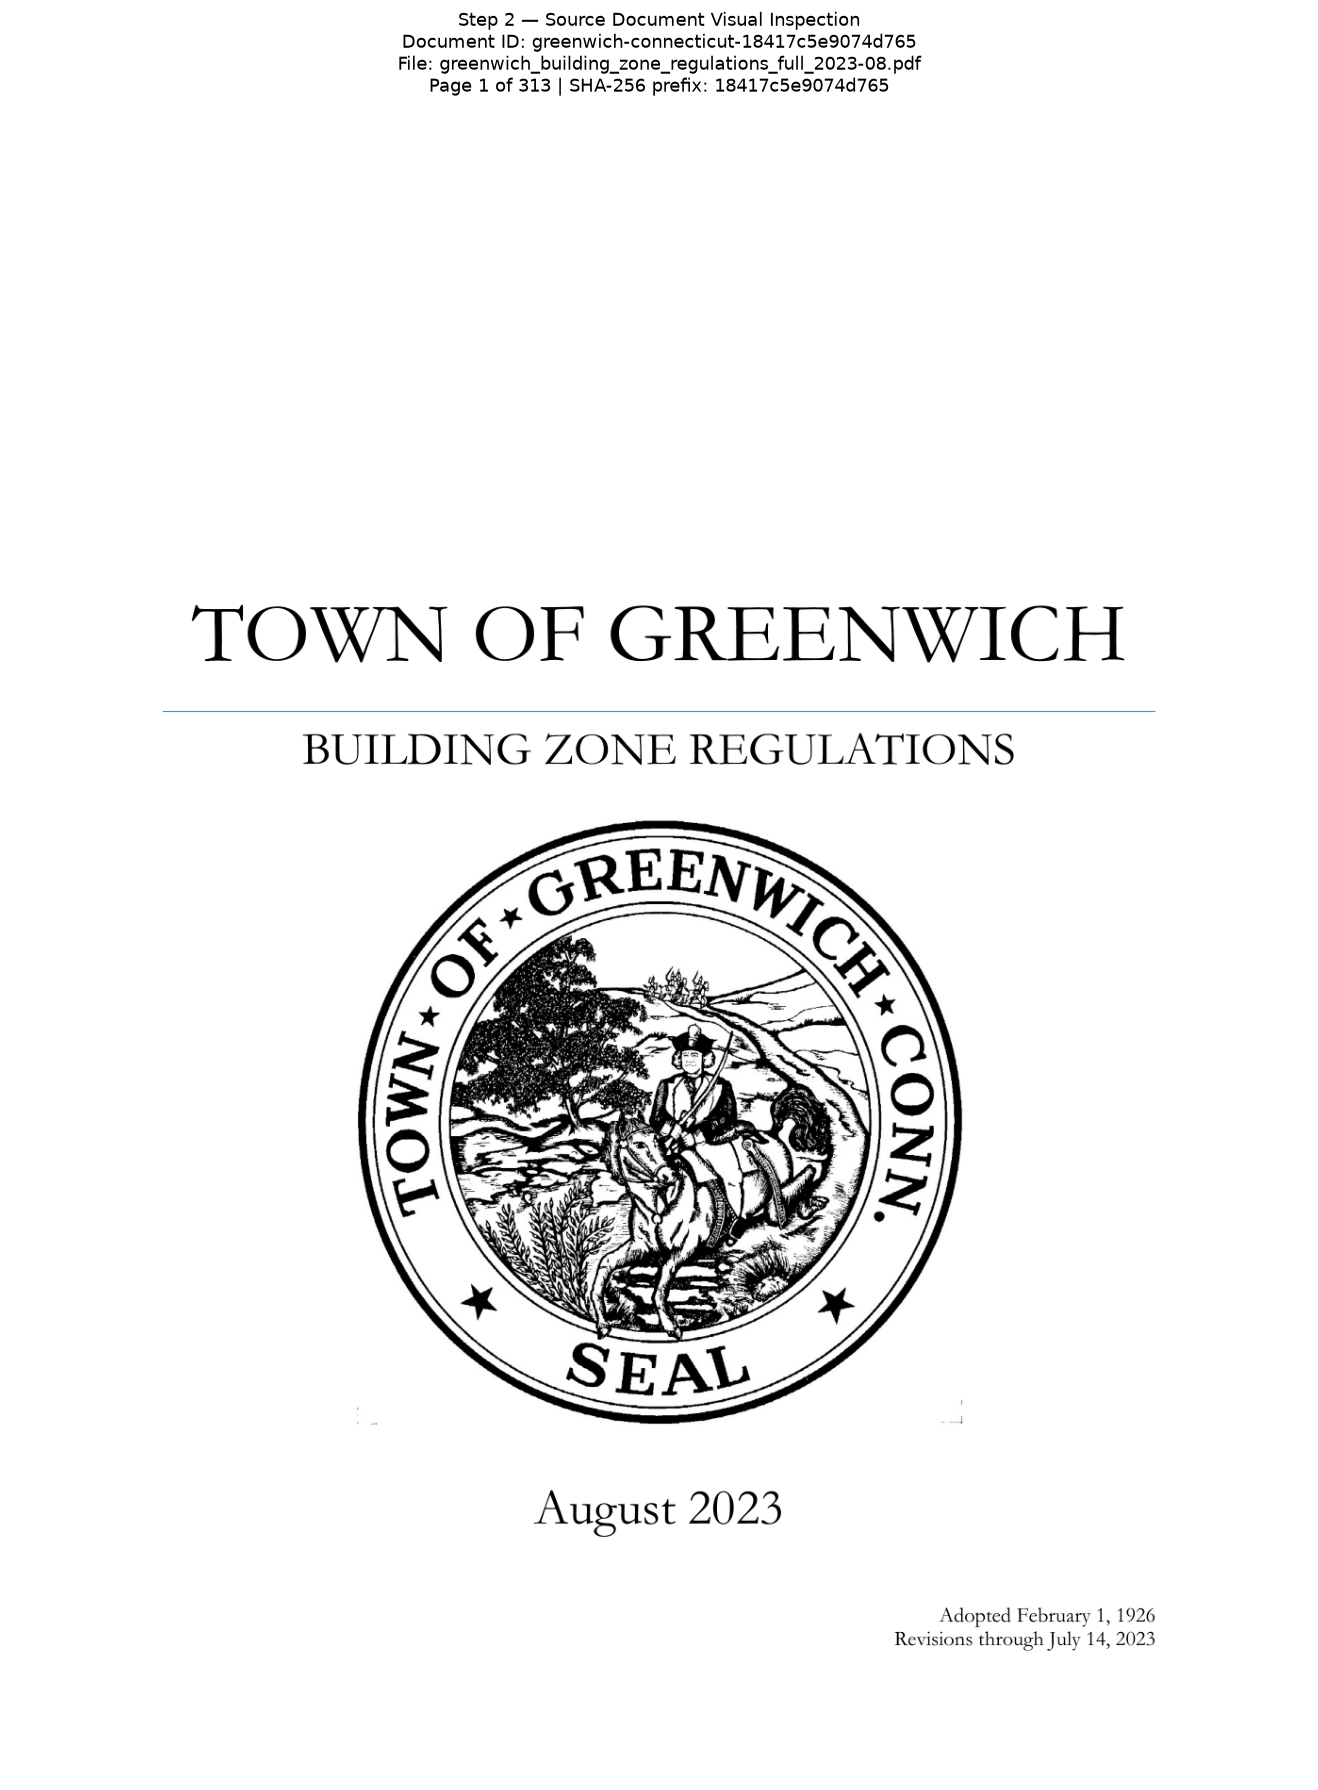

Saved high-resolution source inspection preview: outputs/figures/step_02_document_fingerprint_page_001.png


In [13]:
first_page_image_high_res = render_pdf_page(
    PDF_PATH,
    page_number=1,
    zoom=2.25,
)

fig, ax = plt.subplots(figsize=(14, 18))
ax.imshow(first_page_image_high_res)
ax.set_title(
    "\n".join(
        [
            "Step 2 — Source Document Visual Inspection",
            f"Document ID: {DOCUMENT_ID}",
            f"File: {PDF_PATH.name}",
            f"Page 1 of {PDF_PAGE_COUNT} | SHA-256 prefix: {PDF_SHA256[:16]}",
        ]
    ),
    fontsize=13,
)
ax.axis("off")
plt.tight_layout()

step_2_preview_path = FIGURES_DIR / "step_02_document_fingerprint_page_001.png"
fig.savefig(step_2_preview_path, dpi=250, bbox_inches="tight")

plt.show()

print(
    "Saved high-resolution source inspection preview: "
    f"{step_2_preview_path.relative_to(STAGE_A_ROOT)}"
)

In [14]:
MANUAL_FIRST_PAGE_REVIEW_STATUS = "passed_manual_first_page_review"
MANUAL_FIRST_PAGE_REVIEW_NOTE = (
    "Page 1 visually confirmed as the intended Greenwich Building Zone "
    "Regulations source document."
)

allowed_review_statuses = {
    "passed_manual_first_page_review",
    "flagged_for_source_review",
}

if MANUAL_FIRST_PAGE_REVIEW_STATUS not in allowed_review_statuses:
    raise ValueError(
        "MANUAL_FIRST_PAGE_REVIEW_STATUS must be one of: "
        f"{sorted(allowed_review_statuses)}"
    )

document_metadata_df.loc[
    0, "initial_inspection_status"
] = MANUAL_FIRST_PAGE_REVIEW_STATUS

document_metadata_df["initial_inspection_note"] = MANUAL_FIRST_PAGE_REVIEW_NOTE

document_metadata_df.T.rename(columns={0: "value"})

,value
document_id,greenwich-connecticut-18417c5e9074d765
jurisdiction,"Greenwich, Connecticut"
document_name,Town of Greenwich Building Zone Regulations
document_filename,greenwich_building_zone_regulations_full_2023-...
local_path_relative_to_stage_a,data/raw/greenwich/greenwich_building_zone_reg...
source_url,https://www.greenwichct.gov/442/Building-Zone-...
date_retrieved,2026-09-29
declared_document_version,August 2023
detected_version_candidates,August
version_detection_status,candidate_found


## Step 3 — Native text and layout-metadata extraction

### Objective

Extract the native PDF text layer from every page of the canonical Greenwich zoning-code PDF while preserving page-level spatial and layout provenance.

This step creates two linked datasets:

1. **Word tokens:** individual extracted words with page number, bounding box, block/line/word position, and preliminary reading-order coordinates.
2. **Text spans:** contiguous text segments that share font properties, with font name, font size, flags, color, bounding box, and writing direction.

### Why two levels are retained

Word tokens are useful for later token-level provenance, reading-order reconstruction, and bounding-box validation.

Spans are useful for heading detection because font size, font name, bold/italic indicators, indentation, and line geometry are often stronger heading signals than word text alone.

### Scope boundary

This is native-stream extraction only.

In [15]:
NATIVE_EXTRACTION_CONFIG = {
    "engine": "PyMuPDF",
    "word_extraction_mode": "words",
    "span_extraction_mode": "dict",
    "sort_reading_order": True,
    "include_word_tokens": True,
    "include_text_spans": True,
    "exclude_empty_text": True,
    "minimum_word_length": 1,
    "page_number_base": 1,
    "initial_section_number": None,
    "initial_heading_depth": None,
    "initial_table_id": None,
    "initial_normalized_text_span": None,
    "output_word_tokens_filename": "step_03_native_word_tokens.parquet",
    "output_text_spans_filename": "step_03_native_text_spans.parquet",
    "output_page_summary_filename": "step_03_native_page_summary.csv",
}

NATIVE_EXTRACTION_CONFIG

{'engine': 'PyMuPDF',
 'word_extraction_mode': 'words',
 'span_extraction_mode': 'dict',
 'sort_reading_order': True,
 'include_word_tokens': True,
 'include_text_spans': True,
 'exclude_empty_text': True,
 'minimum_word_length': 1,
 'page_number_base': 1,
 'initial_section_number': None,
 'initial_heading_depth': None,
 'initial_table_id': None,
 'initial_normalized_text_span': None,
 'output_word_tokens_filename': 'step_03_native_word_tokens.parquet',
 'output_text_spans_filename': 'step_03_native_text_spans.parquet',
 'output_page_summary_filename': 'step_03_native_page_summary.csv'}

### Coordinate convention and provisional schema

PyMuPDF returns page coordinates in PDF page units, normally points, using:

$$B_i = (x_0, y_0, x_1, y_1)$$

where:

* $x_0, y_0$ are the upper-left coordinates of the extracted word or span;
* $x_1, y_1$ are the lower-right coordinates;
* each page is numbered using a human-readable 1-based page index.

The word-token table begins the eventual layout-aware token tuple:

$$u_i = \langle T_i, P_i, B_i, S_i, H_i, \Gamma_i, \Delta_i \rangle$$

At this step:

* $T_i$, $P_i$, and $B_i$ are extracted from the native PDF;
* $S_i$, $H_i$, $\Gamma_i$, and $\Delta_i$ remain explicitly unassigned;
* extraction-engine and reading-order fields are added as audit metadata.

In [16]:
def clean_extracted_text(text: str | None) -> str:
    """Normalize surrounding whitespace without changing internal text meaning."""
    if text is None:
        return ""

    return re.sub(r"\s+", " ", text).strip()


def rgb_integer_to_hex(color_value: int | None) -> str | None:
    """
    Convert PyMuPDF's integer RGB color representation to #RRGGBB when present.
    """
    if color_value is None:
        return None

    return f"#{color_value:06x}"


def extract_native_layout_data(
    pdf_path: Path,
    document_id: str,
    config: dict,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Extract word-level and span-level native PDF content with layout provenance.

    Returns:
        word_tokens_df: One row per extracted native word.
        text_spans_df: One row per extracted font-consistent text span.
        page_summary_df: One row per PDF page with basic extraction diagnostics.
    """
    word_records = []
    span_records = []
    page_records = []

    with fitz.open(pdf_path) as document:
        for page_index in range(document.page_count):
            page = document.load_page(page_index)
            page_number = page_index + config["page_number_base"]

            page_rect = page.rect
            page_width = float(page_rect.width)
            page_height = float(page_rect.height)

            words = page.get_text(
                config["word_extraction_mode"],
                sort=config["sort_reading_order"],
            )

            native_page_text = clean_extracted_text(
                page.get_text("text", sort=config["sort_reading_order"])
            )

            text_dict = page.get_text(
                config["span_extraction_mode"],
                sort=config["sort_reading_order"],
            )

            retained_words_on_page = 0

            for extracted_word_index, word in enumerate(words):
                x0, y0, x1, y1, text, block_no, line_no, word_no = word
                text = clean_extracted_text(text)

                if config["exclude_empty_text"] and not text:
                    continue

                if len(text) < config["minimum_word_length"]:
                    continue

                retained_words_on_page += 1

                word_records.append(
                    {
                        "document_id": document_id,
                        "token_id": (
                            f"{document_id}-p{page_number:04d}"
                            f"-w{retained_words_on_page:06d}"
                        ),
                        "text": text,
                        "page_number": page_number,
                        "bbox_x0": float(x0),
                        "bbox_y0": float(y0),
                        "bbox_x1": float(x1),
                        "bbox_y1": float(y1),
                        "bbox_width": float(x1 - x0),
                        "bbox_height": float(y1 - y0),
                        "page_width": page_width,
                        "page_height": page_height,
                        "block_number": int(block_no),
                        "line_number": int(line_no),
                        "word_number_in_line": int(word_no),
                        "native_word_sequence_on_page": retained_words_on_page,
                        "native_word_index_raw": extracted_word_index,
                        "reading_order_source": "pymupdf_words_sort_true",
                        "extraction_engine": "pymupdf_native",
                        "extraction_method": "native_text_stream",
                        "section_number": config["initial_section_number"],
                        "heading_depth": config["initial_heading_depth"],
                        "table_id": config["initial_table_id"],
                        "normalized_text_start": config["initial_normalized_text_span"],
                        "normalized_text_end": config["initial_normalized_text_span"],
                        "token_confidence": None,
                        "review_status": "not_yet_scored",
                    }
                )

            retained_spans_on_page = 0

            for block_index, block in enumerate(text_dict.get("blocks", [])):
                if block.get("type") != 0:
                    continue

                for line_index, line in enumerate(block.get("lines", [])):
                    line_bbox = line.get("bbox", [None, None, None, None])
                    line_direction = line.get("dir", [None, None])
                    writing_mode = line.get("wmode", None)

                    for span_index, span in enumerate(line.get("spans", [])):
                        span_text = clean_extracted_text(span.get("text", ""))

                        if config["exclude_empty_text"] and not span_text:
                            continue

                        retained_spans_on_page += 1

                        x0, y0, x1, y1 = span.get(
                            "bbox",
                            [None, None, None, None],
                        )

                        span_records.append(
                            {
                                "document_id": document_id,
                                "span_id": (
                                    f"{document_id}-p{page_number:04d}"
                                    f"-s{retained_spans_on_page:06d}"
                                ),
                                "text": span_text,
                                "page_number": page_number,
                                "bbox_x0": float(x0) if x0 is not None else None,
                                "bbox_y0": float(y0) if y0 is not None else None,
                                "bbox_x1": float(x1) if x1 is not None else None,
                                "bbox_y1": float(y1) if y1 is not None else None,
                                "bbox_width": (
                                    float(x1 - x0)
                                    if x0 is not None and x1 is not None
                                    else None
                                ),
                                "bbox_height": (
                                    float(y1 - y0)
                                    if y0 is not None and y1 is not None
                                    else None
                                ),
                                "page_width": page_width,
                                "page_height": page_height,
                                "block_number": int(block_index),
                                "line_number": int(line_index),
                                "span_number_in_line": int(span_index),
                                "line_bbox_x0": (
                                    float(line_bbox[0])
                                    if line_bbox[0] is not None
                                    else None
                                ),
                                "line_bbox_y0": (
                                    float(line_bbox[1])
                                    if line_bbox[1] is not None
                                    else None
                                ),
                                "line_bbox_x1": (
                                    float(line_bbox[2])
                                    if line_bbox[2] is not None
                                    else None
                                ),
                                "line_bbox_y1": (
                                    float(line_bbox[3])
                                    if line_bbox[3] is not None
                                    else None
                                ),
                                "line_direction_x": (
                                    float(line_direction[0])
                                    if line_direction[0] is not None
                                    else None
                                ),
                                "line_direction_y": (
                                    float(line_direction[1])
                                    if line_direction[1] is not None
                                    else None
                                ),
                                "writing_mode": writing_mode,
                                "font_name": span.get("font"),
                                "font_size": (
                                    float(span.get("size"))
                                    if span.get("size") is not None
                                    else None
                                ),
                                "font_flags": span.get("flags"),
                                "font_color_hex": rgb_integer_to_hex(
                                    span.get("color")
                                ),
                                "font_ascender": span.get("ascender"),
                                "font_descender": span.get("descender"),
                                "span_origin_x": (
                                    float(span["origin"][0])
                                    if span.get("origin") is not None
                                    else None
                                ),
                                "span_origin_y": (
                                    float(span["origin"][1])
                                    if span.get("origin") is not None
                                    else None
                                ),
                                "native_span_sequence_on_page": retained_spans_on_page,
                                "reading_order_source": "pymupdf_dict_sort_true",
                                "extraction_engine": "pymupdf_native",
                                "extraction_method": "native_text_stream",
                                "section_number": config["initial_section_number"],
                                "heading_depth": config["initial_heading_depth"],
                                "table_id": config["initial_table_id"],
                                "normalized_text_start": config["initial_normalized_text_span"],
                                "normalized_text_end": config["initial_normalized_text_span"],
                                "span_confidence": None,
                                "review_status": "not_yet_scored",
                            }
                        )

            page_records.append(
                {
                    "document_id": document_id,
                    "page_number": page_number,
                    "page_width": page_width,
                    "page_height": page_height,
                    "native_word_count": retained_words_on_page,
                    "native_span_count": retained_spans_on_page,
                    "native_text_character_count": len(native_page_text),
                    "native_text_preview": native_page_text[:500],
                    "extraction_engine": "pymupdf_native",
                    "extraction_method": "native_text_stream",
                    "review_status": "not_yet_scored",
                }
            )

    return (
        pd.DataFrame(word_records),
        pd.DataFrame(span_records),
        pd.DataFrame(page_records),
    )

In [17]:
word_tokens_df, text_spans_df, native_page_summary_df = extract_native_layout_data(
    pdf_path=PDF_PATH,
    document_id=DOCUMENT_ID,
    config=NATIVE_EXTRACTION_CONFIG,
)

assert len(native_page_summary_df) == PDF_PAGE_COUNT, (
    "The page summary must contain exactly one row for every PDF page."
)

assert word_tokens_df["page_number"].between(1, PDF_PAGE_COUNT).all(), (
    "Every word token must have a valid 1-based page number."
)

assert text_spans_df["page_number"].between(1, PDF_PAGE_COUNT).all(), (
    "Every text span must have a valid 1-based page number."
)

print(f"Pages processed: {len(native_page_summary_df):,}")
print(f"Native word tokens extracted: {len(word_tokens_df):,}")
print(f"Native text spans extracted: {len(text_spans_df):,}")
print(
    "Pages with zero native words: "
    f"{(native_page_summary_df['native_word_count'] == 0).sum():,}"
)

Pages processed: 313
Native word tokens extracted: 125,276
Native text spans extracted: 17,550
Pages with zero native words: 0


### Token-level extraction preview

The table below is the initial machine-readable representation of native text tokens.

At this stage, the extracted fields correspond to:

- \(T_i\): `text`
- \(P_i\): `page_number`
- \(B_i\): `bbox_x0`, `bbox_y0`, `bbox_x1`, `bbox_y1`

The following fields intentionally remain empty until later collection steps:

- `section_number`
- `heading_depth`
- `table_id`
- `normalized_text_start`
- `normalized_text_end`

The word-level order fields are a preliminary, engine-reported reading sequence. They will be evaluated by the page-quality and reading-order checks in the next step.

In [18]:
word_preview_columns = [
    "token_id",
    "text",
    "page_number",
    "bbox_x0",
    "bbox_y0",
    "bbox_x1",
    "bbox_y1",
    "block_number",
    "line_number",
    "word_number_in_line",
    "native_word_sequence_on_page",
    "section_number",
    "heading_depth",
    "table_id",
    "review_status",
]

word_tokens_df[word_preview_columns].head(30)

,token_id,text,page_number,bbox_x0,bbox_y0,bbox_x1,bbox_y1,block_number,line_number,word_number_in_line,native_word_sequence_on_page,section_number,heading_depth,table_id,review_status
0,greenwich-connecticut-18417c5e9074d765-p0001-w...,TOWN,1,85.800003,224.599442,207.829834,276.267731,1,0,0,1,None,None,None,not_yet_scored
1,greenwich-connecticut-18417c5e9074d765-p0001-w...,OF,1,217.819824,224.599442,271.514069,276.267731,1,0,1,2,None,None,None,not_yet_scored
2,greenwich-connecticut-18417c5e9074d765-p0001-w...,GREENWICH,1,281.528076,224.599442,526.227173,276.267731,1,0,2,3,None,None,None,not_yet_scored
3,greenwich-connecticut-18417c5e9074d765-p0001-w...,BUILDING,1,137.759995,291.427429,245.891022,319.821716,2,0,0,4,None,None,None,not_yet_scored
4,greenwich-connecticut-18417c5e9074d765-p0001-w...,ZONE,1,251.391998,291.427429,314.274445,319.821716,2,0,1,5,None,None,None,not_yet_scored
5,greenwich-connecticut-18417c5e9074d765-p0001-w...,REGULATIONS,1,319.915985,291.427429,473.949982,319.821716,2,0,2,6,None,None,None,not_yet_scored
6,greenwich-connecticut-18417c5e9074d765-p0001-w...,August,1,247.320007,647.496033,313.608032,678.528015,3,1,0,7,None,None,None,not_yet_scored
7,greenwich-connecticut-18417c5e9074d765-p0001-w...,2023,1,319.559998,647.496033,364.656006,678.528015,3,1,1,8,None,None,None,not_yet_scored
8,greenwich-connecticut-18417c5e9074d765-p0001-w...,Adopted,1,438.119141,707.534668,472.019012,720.412964,5,0,0,9,None,None,None,not_yet_scored
9,greenwich-connecticut-18417c5e9074d765-p0001-w...,February,1,474.598663,707.534668,509.351074,720.412964,5,0,1,10,None,None,None,not_yet_scored


In [19]:
span_preview_columns = [
    "span_id",
    "text",
    "page_number",
    "bbox_x0",
    "bbox_y0",
    "bbox_x1",
    "bbox_y1",
    "font_name",
    "font_size",
    "font_flags",
    "font_color_hex",
    "block_number",
    "line_number",
    "span_number_in_line",
    "line_direction_x",
    "line_direction_y",
]

text_spans_df[span_preview_columns].head(30)

,span_id,text,page_number,bbox_x0,bbox_y0,bbox_x1,bbox_y1,font_name,font_size,font_flags,font_color_hex,block_number,line_number,span_number_in_line,line_direction_x,line_direction_y
0,greenwich-connecticut-18417c5e9074d765-p0001-s...,TOWN OF GREENWICH,1,85.800003,224.599442,536.189148,276.267731,Garamond,39.959999,4,#000000,1,0,0,1.0,0.0
1,greenwich-connecticut-18417c5e9074d765-p0001-s...,BUILDING ZONE REGULATIONS,1,137.759995,291.427429,473.949982,319.821716,Garamond,21.959999,4,#000000,2,0,0,1.0,0.0
2,greenwich-connecticut-18417c5e9074d765-p0001-s...,August 2023,1,247.320007,647.496033,370.559998,678.528015,Garamond,24.000000,4,#000000,4,1,0,1.0,0.0
3,greenwich-connecticut-18417c5e9074d765-p0001-s...,"Adopted February 1, 1926",1,438.119141,707.534668,542.494019,720.412964,Garamond,9.960000,4,#000000,6,0,0,1.0,0.0
4,greenwich-connecticut-18417c5e9074d765-p0001-s...,"Revisions through July 14, 2023",1,416.874451,718.819336,542.489014,731.697632,Garamond,9.960000,4,#000000,6,1,0,1.0,0.0
5,greenwich-connecticut-18417c5e9074d765-p0002-s...,BUILDING ZONE REGULATIONS,2,211.320007,70.487976,403.679993,87.095970,TimesNewRomanPS-BoldMT,12.000000,20,#000000,0,0,0,1.0,0.0
6,greenwich-connecticut-18417c5e9074d765-p0002-s...,OF THE,2,283.440002,84.287964,331.440002,100.895958,TimesNewRomanPS-BoldMT,12.000000,20,#000000,1,0,0,1.0,0.0
7,greenwich-connecticut-18417c5e9074d765-p0002-s...,TOWN OF GREENWICH,2,237.000000,98.087952,378.000000,114.695946,TimesNewRomanPS-BoldMT,12.000000,20,#000000,1,1,0,1.0,0.0
8,greenwich-connecticut-18417c5e9074d765-p0002-s...,CONNECTICUT,2,261.000000,111.887939,354.000000,128.495941,TimesNewRomanPS-BoldMT,12.000000,20,#000000,2,0,0,1.0,0.0
9,greenwich-connecticut-18417c5e9074d765-p0002-s...,PLANNING AND ZONING COMMISSION,2,191.399994,167.088013,423.480316,183.696014,TimesNewRomanPS-BoldMT,12.000000,20,#000000,4,0,0,1.0,0.0


### Multi-page native-text samples

A full-document token count can hide localized failures. The samples below inspect early, middle, and late pages to detect obvious issues such as:

- blank native extraction
- unreadable character sequences
- broken word order
- repeated headers/footers dominating the text
- pages that appear to be scans rather than native text
- an incorrect document being processed

These samples are not yet scored. They are a quick visual diagnostic before automated quality routing

In [20]:
sample_page_numbers = sorted(
    set(
        [
            1,
            max(1, PDF_PAGE_COUNT // 2),
            PDF_PAGE_COUNT,
        ]
    )
)

text_sample_rows = []

for page_number in sample_page_numbers:
    page_row = native_page_summary_df.loc[
        native_page_summary_df["page_number"] == page_number
    ].iloc[0]

    text_sample_rows.append(
        {
            "page_number": page_number,
            "native_word_count": page_row["native_word_count"],
            "native_span_count": page_row["native_span_count"],
            "native_text_character_count": page_row[
                "native_text_character_count"
            ],
            "native_text_sample": page_row["native_text_preview"],
        }
    )

native_text_samples_df = pd.DataFrame(text_sample_rows)

for _, sample_row in native_text_samples_df.iterrows():
    print("=" * 100)
    print(
        f"PAGE {int(sample_row['page_number'])} | "
        f"words={int(sample_row['native_word_count'])} | "
        f"spans={int(sample_row['native_span_count'])} | "
        f"characters={int(sample_row['native_text_character_count'])}"
    )
    print("-" * 100)
    print(sample_row["native_text_sample"])
    print()

PAGE 1 | words=17 | spans=5 | characters=112
----------------------------------------------------------------------------------------------------
TOWN OF GREENWICH BUILDING ZONE REGULATIONS August 2023 Adopted February 1, 1926 Revisions through July 14, 2023

PAGE 156 | words=578 | spans=60 | characters=3637
----------------------------------------------------------------------------------------------------
§6-139.1 GREENWICH MUNICIPAL CODE §6-139.1 approximate (rounded up or down) and should be verified with the BFEs published in the FIS for a specific location. The determination of areas of special flood hazard shall be based on the flood elevations shown on the FIRM and published in the FIS in conjunction with an up-to-date and accurate topographical survey of the site prepared by a Connecticut Licensed Land Surveyor. Areas of special flood hazard shall also include areas where the land surface 

PAGE 313 | words=166 | spans=19 | characters=963
--------------------------------------

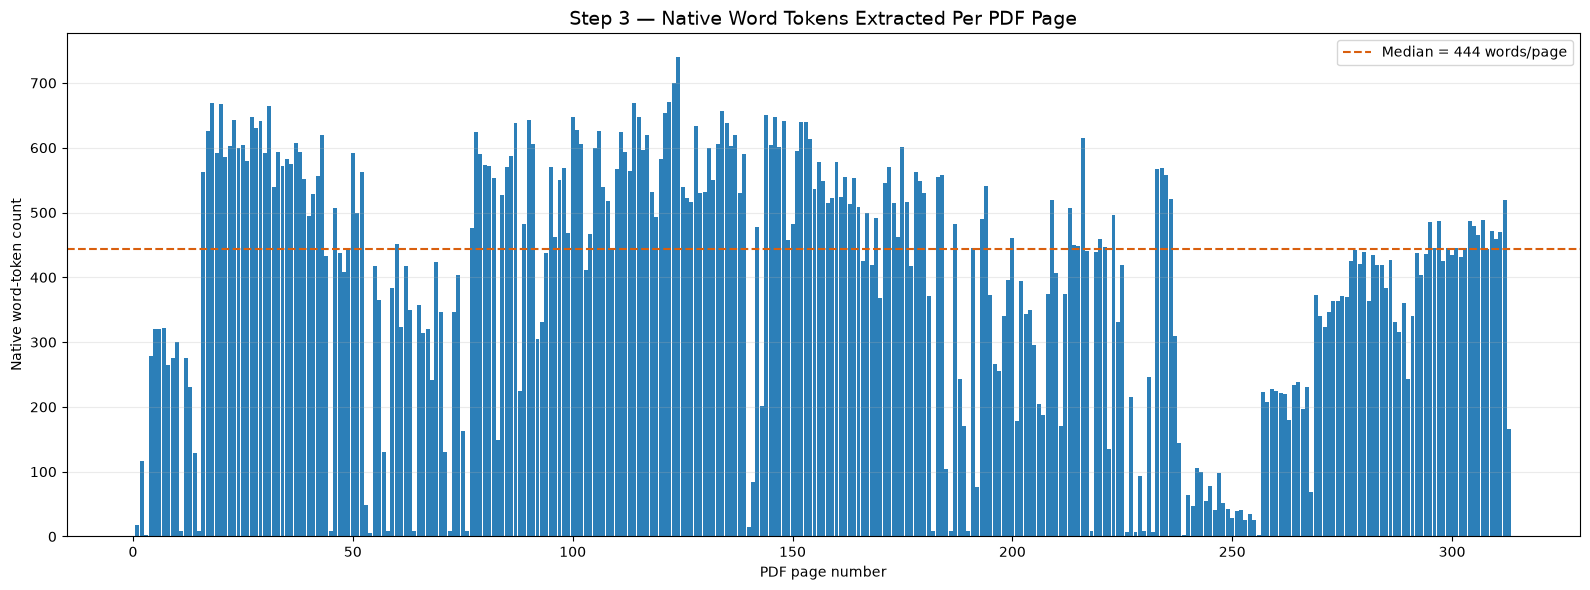

Saved words-per-page chart: outputs/figures/step_03_native_words_per_page.png


In [21]:
fig, ax = plt.subplots(figsize=(16, 6))

ax.bar(
    native_page_summary_df["page_number"],
    native_page_summary_df["native_word_count"],
    color="#2C7FB8",
    width=0.9,
)

ax.axhline(
    native_page_summary_df["native_word_count"].median(),
    color="#D95F0E",
    linestyle="--",
    linewidth=1.5,
    label=(
        "Median = "
        f"{native_page_summary_df['native_word_count'].median():.0f} words/page"
    ),
)

ax.set_title("Step 3 — Native Word Tokens Extracted Per PDF Page", fontsize=14)
ax.set_xlabel("PDF page number")
ax.set_ylabel("Native word-token count")
ax.legend()
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()

words_per_page_figure_path = FIGURES_DIR / "step_03_native_words_per_page.png"
fig.savefig(words_per_page_figure_path, dpi=220, bbox_inches="tight")
plt.show()

print(
    "Saved words-per-page chart: "
    f"{words_per_page_figure_path.relative_to(STAGE_A_ROOT)}"
)

### Spatial overlay validation

The following visualizations draw a sampled set of extracted word bounding boxes on top of rendered PDF pages

These overlays verify that:

- extracted words map to the visible text on the page
- PDF coordinate orientation is correct
- boxes are not systematically shifted, inverted, or scaled incorrectly
- reading-order sequence roughly proceeds from top to bottom and left to right
- complex formatting such as tables, headers, sidebars, or multi-column content can be identified for later quality scoring

A small sample is shown rather than every word on the page, because drawing every box would make the page unreadable

In [22]:
from matplotlib.patches import Rectangle


def plot_token_overlay(
    pdf_path: Path,
    tokens_df: pd.DataFrame,
    page_number: int,
    sample_size: int = 80,
    zoom: float = 1.5,
    seed: int = 42,
) -> tuple[plt.Figure, plt.Axes]:
    """
    Render a page and overlay sampled native-word bounding boxes.

    Tokens are sampled reproducibly. The first few tokens in preliminary
    reading order are included so labels help visually verify the sequence.
    """
    page_tokens = tokens_df.loc[
        tokens_df["page_number"] == page_number
    ].copy()

    if page_tokens.empty:
        raise ValueError(f"No word tokens were extracted for page {page_number}.")

    page_tokens = page_tokens.sort_values("native_word_sequence_on_page")

    first_tokens = page_tokens.head(min(15, len(page_tokens)))

    remaining_tokens = page_tokens.iloc[len(first_tokens):]

    sample_count = min(
        max(sample_size - len(first_tokens), 0),
        len(remaining_tokens),
    )

    sampled_remaining = (
        remaining_tokens.sample(n=sample_count, random_state=seed)
        if sample_count > 0
        else remaining_tokens.head(0)
    )

    overlay_tokens = (
        pd.concat([first_tokens, sampled_remaining])
        .drop_duplicates(subset="token_id")
        .sort_values("native_word_sequence_on_page")
    )

    page_image = render_pdf_page(
        pdf_path=pdf_path,
        page_number=page_number,
        zoom=zoom,
    )

    page_height_points = float(page_tokens["page_height"].iloc[0])

    fig, ax = plt.subplots(figsize=(13, 17))
    ax.imshow(page_image)

    scale = zoom

    for _, token in overlay_tokens.iterrows():
        x0 = token["bbox_x0"] * scale
        y0 = token["bbox_y0"] * scale
        width = token["bbox_width"] * scale
        height = token["bbox_height"] * scale

        is_early_sequence_token = (
            token["native_word_sequence_on_page"]
            <= len(first_tokens)
        )

        rectangle_color = "#E31A1C" if is_early_sequence_token else "#1F78B4"

        rectangle = Rectangle(
            (x0, y0),
            width,
            height,
            linewidth=0.8,
            edgecolor=rectangle_color,
            facecolor="none",
            alpha=0.8,
        )

        ax.add_patch(rectangle)

        if is_early_sequence_token:
            ax.text(
                x0,
                max(0, y0 - 3),
                str(int(token["native_word_sequence_on_page"])),
                color=rectangle_color,
                fontsize=6,
                bbox={
                    "facecolor": "white",
                    "edgecolor": "none",
                    "alpha": 0.75,
                    "pad": 0.5,
                },
            )

    ax.set_title(
        "\n".join(
            [
                "Step 3 — Native Word Bounding-Box Overlay",
                f"Page {page_number} | "
                f"{len(page_tokens):,} extracted words | "
                f"{len(overlay_tokens):,} displayed boxes",
                "Red + labels: earliest reading-order words; "
                "blue: reproducible random sample",
            ]
        ),
        fontsize=12,
    )
    ax.axis("off")

    return fig, ax

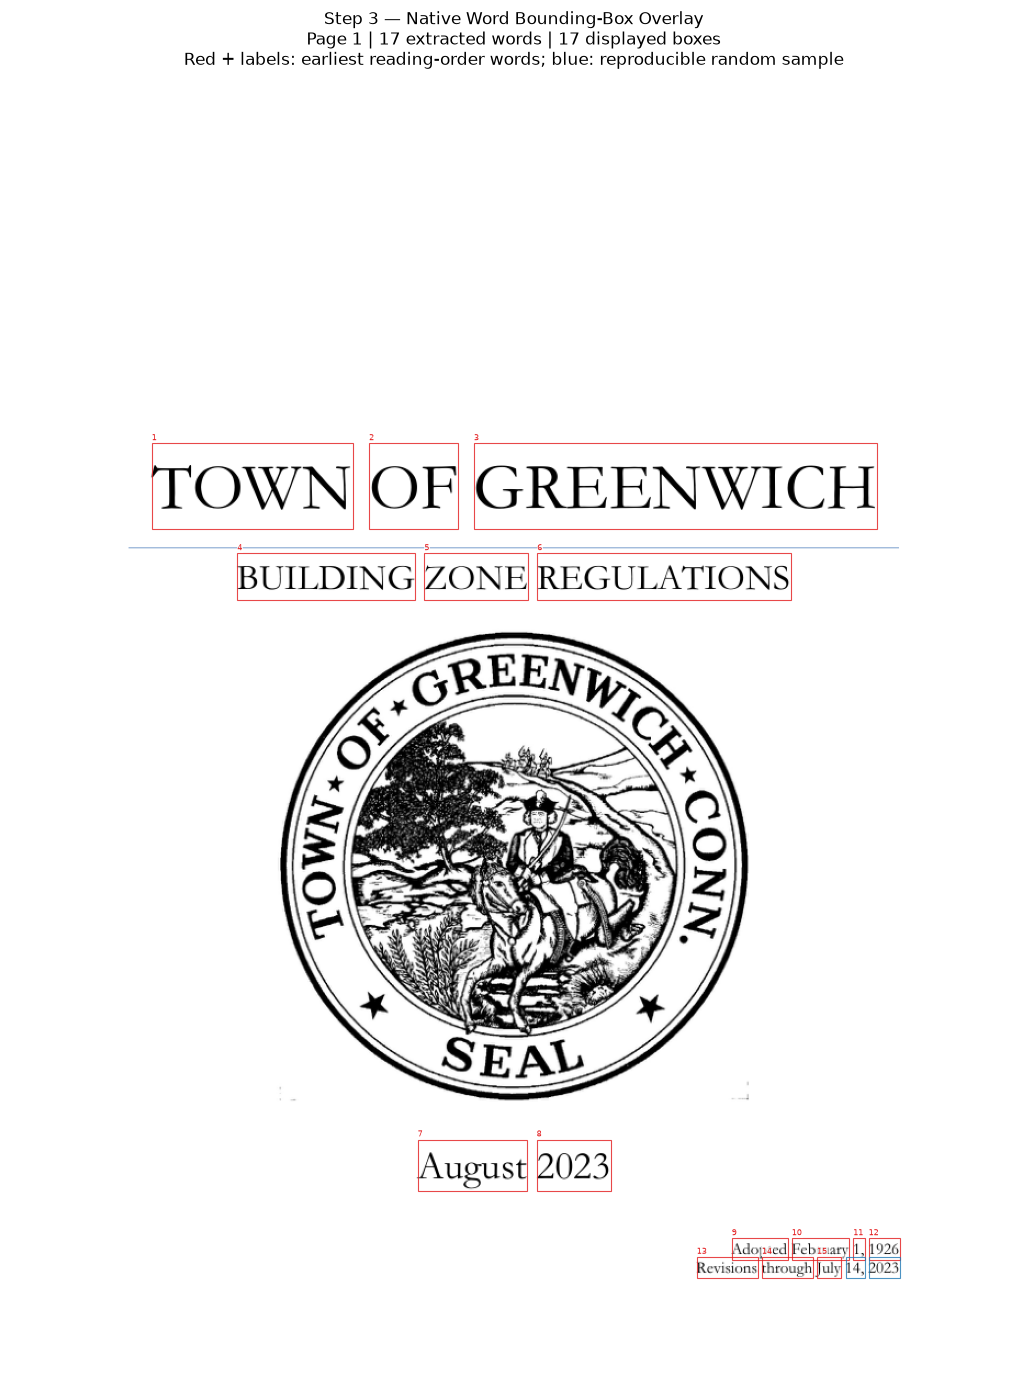

Saved page-1 token overlay: outputs/figures/step_03_native_word_bbox_overlay_page_001.png


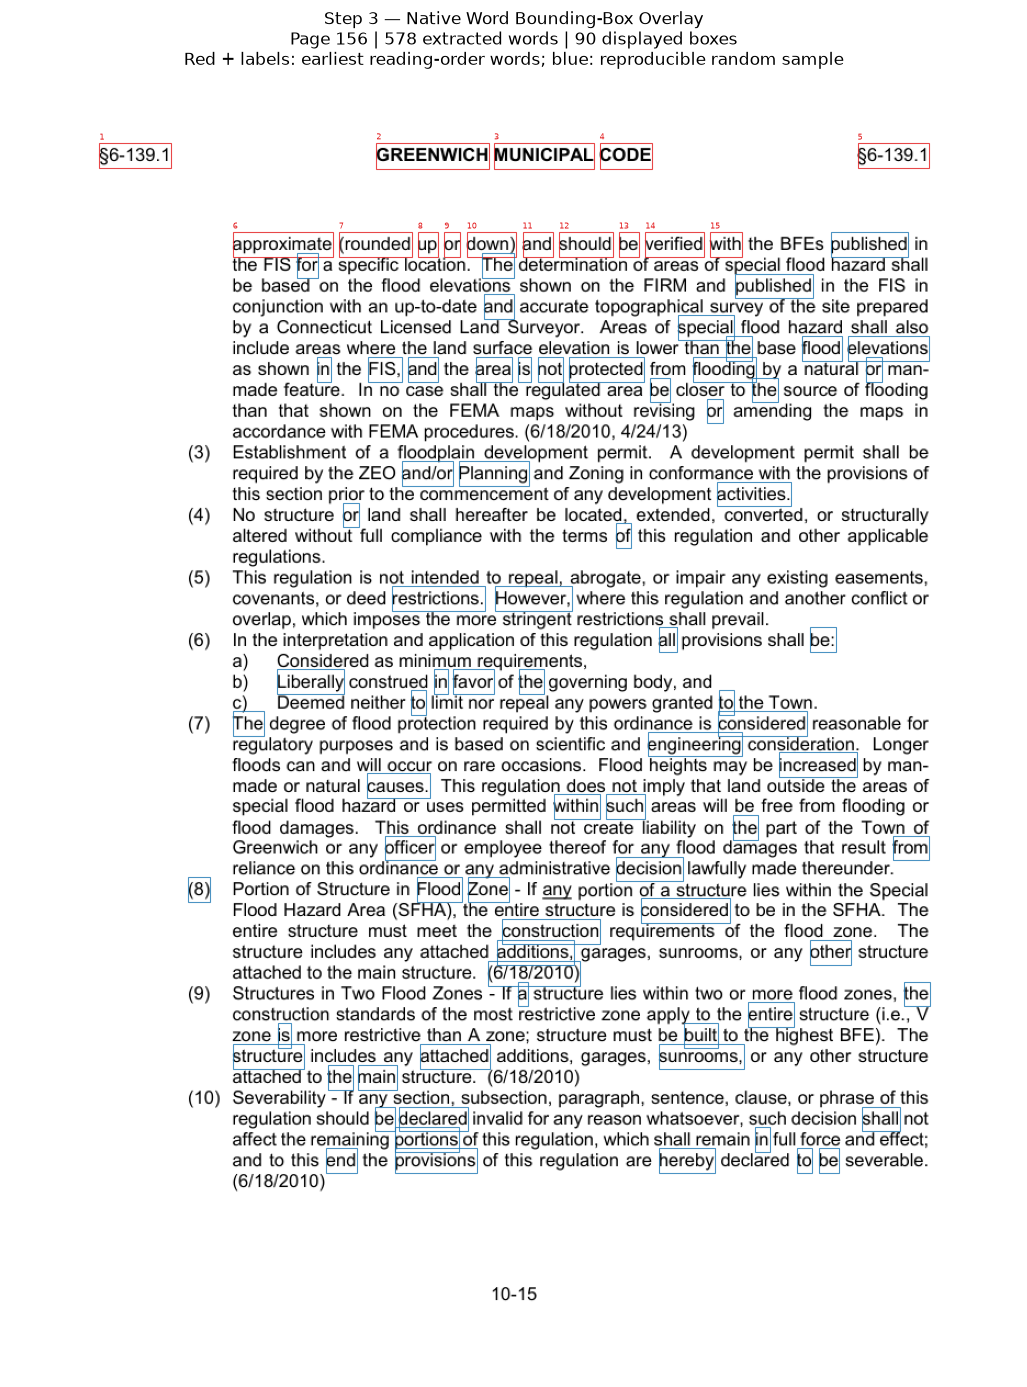

Saved page-156 token overlay: outputs/figures/step_03_native_word_bbox_overlay_page_156.png


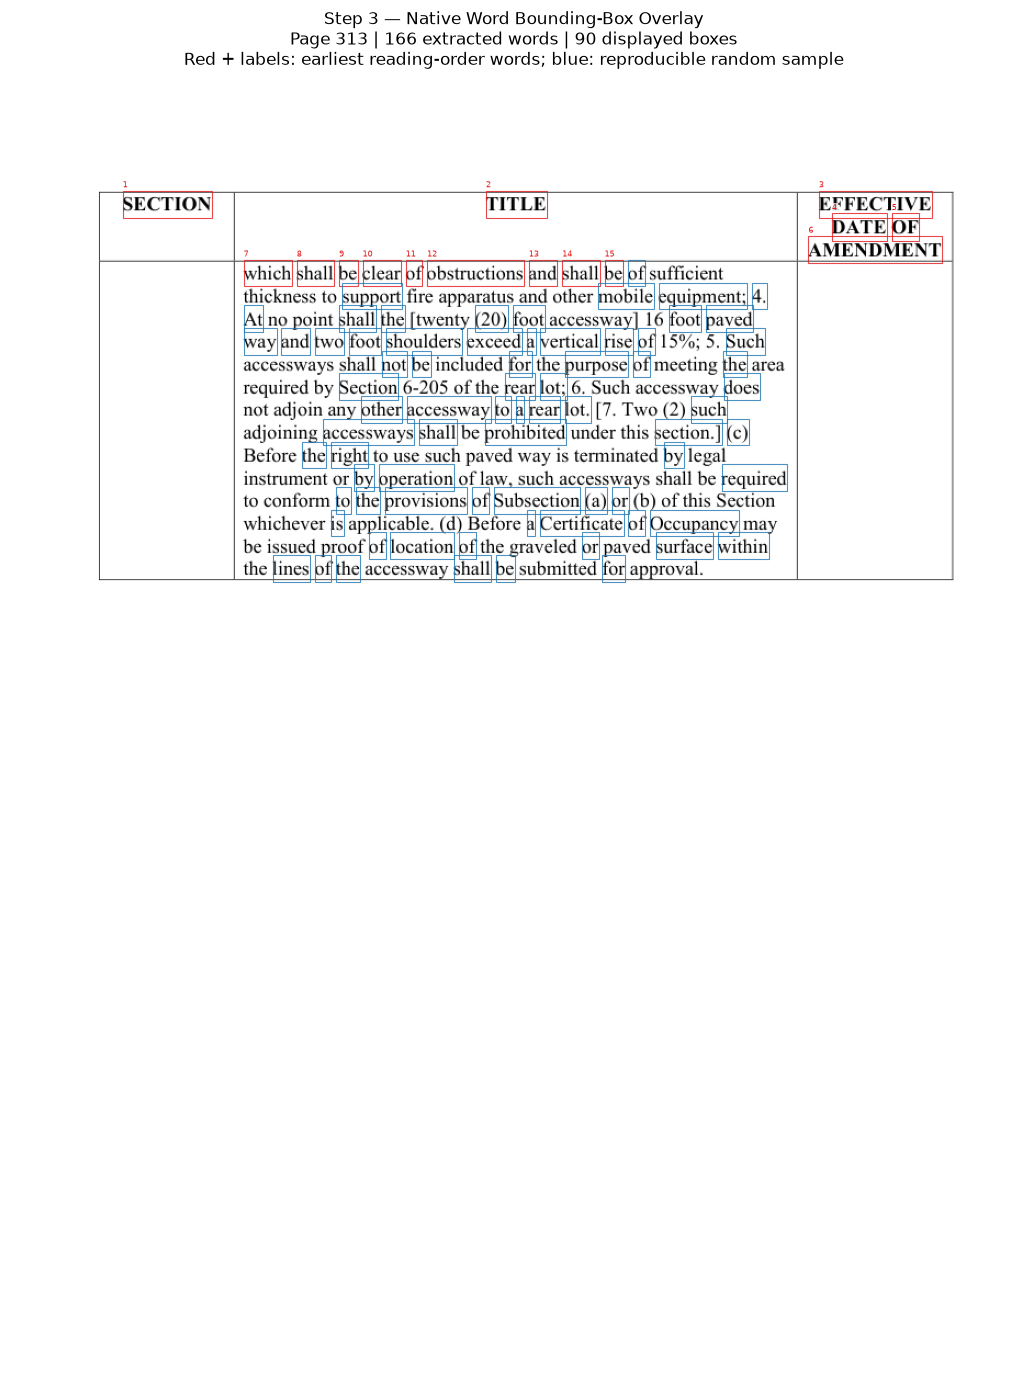

Saved page-313 token overlay: outputs/figures/step_03_native_word_bbox_overlay_page_313.png


In [23]:
overlay_page_numbers = sorted(
    set(
        [
            1,
            max(1, PDF_PAGE_COUNT // 2),
            PDF_PAGE_COUNT,
        ]
    )
)

overlay_paths = []

for page_number in overlay_page_numbers:
    page_word_count = int(
        native_page_summary_df.loc[
            native_page_summary_df["page_number"] == page_number,
            "native_word_count",
        ].iloc[0]
    )

    if page_word_count == 0:
        print(
            f"Skipping page {page_number}: no native word tokens were extracted."
        )
        continue

    fig, ax = plot_token_overlay(
        pdf_path=PDF_PATH,
        tokens_df=word_tokens_df,
        page_number=page_number,
        sample_size=90,
        zoom=1.5,
        seed=42,
    )

    overlay_path = (
        FIGURES_DIR / f"step_03_native_word_bbox_overlay_page_{page_number:03d}.png"
    )

    fig.savefig(overlay_path, dpi=220, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    overlay_paths.append(overlay_path)

    print(
        f"Saved page-{page_number} token overlay: "
        f"{overlay_path.relative_to(STAGE_A_ROOT)}"
    )

### Extraction diagnostics and source artifacts

The final cells for this step summarize the native extraction and save the raw layout-aware datasets

These files are intermediate evidence, not final cleaned zoning-code records:

- The word-token dataset is the starting point for page-quality scoring and later normalized-text construction
- The span dataset is the starting point for typography-aware heading detection
- The page summary is the input to the next step's page-level quality score
- The text samples and visual overlays are inspection artifacts for validating extraction quality

The raw source PDF remains untouched

In [24]:
native_extraction_diagnostics_df = pd.DataFrame(
    [
        {
            "document_id": DOCUMENT_ID,
            "pdf_page_count": PDF_PAGE_COUNT,
            "pages_processed": len(native_page_summary_df),
            "total_native_word_tokens": len(word_tokens_df),
            "total_native_text_spans": len(text_spans_df),
            "median_words_per_page": round(
                native_page_summary_df["native_word_count"].median(),
                2,
            ),
            "mean_words_per_page": round(
                native_page_summary_df["native_word_count"].mean(),
                2,
            ),
            "minimum_words_on_a_page": int(
                native_page_summary_df["native_word_count"].min()
            ),
            "maximum_words_on_a_page": int(
                native_page_summary_df["native_word_count"].max()
            ),
            "pages_with_zero_native_words": int(
                (native_page_summary_df["native_word_count"] == 0).sum()
            ),
            "pages_with_under_20_native_words": int(
                (native_page_summary_df["native_word_count"] < 20).sum()
            ),
            "unique_font_names": int(text_spans_df["font_name"].nunique()),
            "font_size_min": round(text_spans_df["font_size"].min(), 2),
            "font_size_median": round(text_spans_df["font_size"].median(), 2),
            "font_size_max": round(text_spans_df["font_size"].max(), 2),
            "extraction_engine": "pymupdf_native",
            "next_step": "page_quality_scoring_and_routing",
        }
    ]
)

native_extraction_diagnostics_df.T.rename(columns={0: "value"})

,value
document_id,greenwich-connecticut-18417c5e9074d765
pdf_page_count,313
pages_processed,313
total_native_word_tokens,125276
total_native_text_spans,17550
median_words_per_page,444.0
mean_words_per_page,400.24
minimum_words_on_a_page,2
maximum_words_on_a_page,740
pages_with_zero_native_words,0


In [25]:
word_tokens_path = (
    INTERIM_DIR / NATIVE_EXTRACTION_CONFIG["output_word_tokens_filename"]
)
text_spans_path = (
    INTERIM_DIR / NATIVE_EXTRACTION_CONFIG["output_text_spans_filename"]
)
page_summary_path = (
    TABLES_DIR / NATIVE_EXTRACTION_CONFIG["output_page_summary_filename"]
)
diagnostics_path = TABLES_DIR / "step_03_native_extraction_diagnostics.csv"
text_samples_path = TABLES_DIR / "step_03_native_text_samples.csv"

word_tokens_df.to_parquet(word_tokens_path, index=False)
text_spans_df.to_parquet(text_spans_path, index=False)
native_page_summary_df.to_csv(page_summary_path, index=False)
native_extraction_diagnostics_df.to_csv(diagnostics_path, index=False)
native_text_samples_df.to_csv(text_samples_path, index=False)

step_3_log = {
    "document_id": DOCUMENT_ID,
    "pdf_path_relative_to_stage_a": str(PDF_PATH.relative_to(STAGE_A_ROOT)),
    "native_extraction_config": NATIVE_EXTRACTION_CONFIG,
    "word_token_count": len(word_tokens_df),
    "text_span_count": len(text_spans_df),
    "page_count": PDF_PAGE_COUNT,
    "words_per_page_figure": str(
        words_per_page_figure_path.relative_to(STAGE_A_ROOT)
    ),
    "bbox_overlay_figures": [
        str(path.relative_to(STAGE_A_ROOT)) for path in overlay_paths
    ],
}

step_3_log_path = LOGS_DIR / "step_03_native_extraction_log.json"

with step_3_log_path.open("w", encoding="utf-8") as file_handle:
    json.dump(step_3_log, file_handle, indent=2, ensure_ascii=False)

print(
    f"Saved native word tokens: {word_tokens_path.relative_to(STAGE_A_ROOT)}"
)
print(
    f"Saved native text spans: {text_spans_path.relative_to(STAGE_A_ROOT)}"
)
print(
    f"Saved page summary: {page_summary_path.relative_to(STAGE_A_ROOT)}"
)
print(
    f"Saved extraction diagnostics: "
    f"{diagnostics_path.relative_to(STAGE_A_ROOT)}"
)
print(
    f"Saved text samples: {text_samples_path.relative_to(STAGE_A_ROOT)}"
)
print(
    f"Saved extraction log: {step_3_log_path.relative_to(STAGE_A_ROOT)}"
)

Saved native word tokens: data/interim/step_03_native_word_tokens.parquet
Saved native text spans: data/interim/step_03_native_text_spans.parquet
Saved page summary: outputs/tables/step_03_native_page_summary.csv
Saved extraction diagnostics: outputs/tables/step_03_native_extraction_diagnostics.csv
Saved text samples: outputs/tables/step_03_native_text_samples.csv
Saved extraction log: outputs/logs/step_03_native_extraction_log.json
